# 📊 Generación de Figuras del Artículo — CAP Sleep Database

**Notebook 3 (último) del pipeline.** Se ejecuta después de:

1. `Reetiquetado_Hipnograma.ipynb` (notebook 0)
2. `Extraccion_Caracteristicas_Fases.ipynb` (notebook 1)
3. `Modelado_Fases_Sueno.ipynb` (notebook 2)

### Qué hace

Lee los outputs CSV de los notebooks anteriores y genera **11 figuras** en
alta resolución (300 dpi) con estilo consistente, numeradas según
aparecerán en el artículo. Cada figura se exporta como PNG y PDF (vectorial
para LaTeX). Todas usan la misma paleta y tipografía para parecer parte de
un mismo documento.

### Figuras producidas

| # | Figura | Sección del artículo |
|---|--------|---------------------|
| 1 | Pipeline metodológico | Methodology |
| 2 | Ejemplo de hipnograma | Dataset |
| 3 | Distribución de fases | Dataset |
| 4 | Frecuencias de muestreo | Dataset |
| 5 | Perfil espectral por fase | Feature engineering |
| 6 | Boxplots de features clave | Feature engineering |
| 7 | Comparación de modelos | Results |
| 8 | Matrices de confusión | Results |
| 9 | Recall por fase × modelo | Results |
| 10 | Importancia de features | Discussion |
| 11 | Comparación con literatura | Discussion |

## 1. Configuración global de estilo

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns

# ── Rutas ──
HYPNO_DIR    = Path.cwd() / '../data/hypnograms'
FEATURES_DIR = Path.cwd() / '../data/features_fases'
RESULTS_DIR  = Path.cwd() / '../data/results_fases'
FIG_DIR      = Path.cwd() / '../data/figuras_articulo'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Estilo unificado para todas las figuras ──
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.family': 'serif',           # estilo científico
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.labelweight': 'normal',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'legend.fontsize': 10,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})
sns.set_palette('viridis')

# Paleta consistente para fases de sueño
PALETA_FASES = {
    'W':   '#E74C3C',    # rojo (vigilia)
    'S1':  '#F39C12',    # naranja (transición)
    'N1':  '#F39C12',
    'S2':  '#3498DB',    # azul (sueño ligero)
    'N2':  '#3498DB',
    'S3':  '#16A085',    # verde-azul (profundo)
    'S4':  '#27AE60',    # verde (más profundo)
    'N3':  '#16A085',
    'REM': '#9B59B6',    # púrpura (REM)
}

# Paleta para modelos
PALETA_MODELOS = {
    'Random Forest': '#27AE60',
    'XGBoost':       '#E67E22',
    'SVM (RBF)':     '#3498DB',
}

CLASES_RK   = ['W', 'S1', 'S2', 'S3', 'S4', 'REM']
CLASES_AASM = ['W', 'N1', 'N2', 'N3', 'REM']

def guardar_figura(fig, nombre, n_figura):
    '''Guarda figura como PNG (preview) y PDF (para LaTeX vectorial).'''
    base = FIG_DIR / f'fig{n_figura:02d}_{nombre}'
    fig.savefig(f'{base}.png', dpi=300, bbox_inches='tight')
    fig.savefig(f'{base}.pdf', bbox_inches='tight')
    print(f'  ✓ Figura {n_figura}: {base.name}.{{png,pdf}}')

print(f'Directorio de figuras: {FIG_DIR.resolve()}')
print(f'Cada figura se guarda como .png (300 dpi) y .pdf (vectorial)')

Directorio de figuras: D:\Repos\RAHBFDP-2026\data\figuras_articulo
Cada figura se guarda como .png (300 dpi) y .pdf (vectorial)


## Figura 1 — Pipeline metodológico

Diagrama esquemático del flujo completo: anotación → señal EDF →
sincronización → extracción → modelado → evaluación. Se genera
programáticamente con matplotlib (no requiere herramientas externas).

  ✓ Figura 1: fig01_pipeline.{png,pdf}


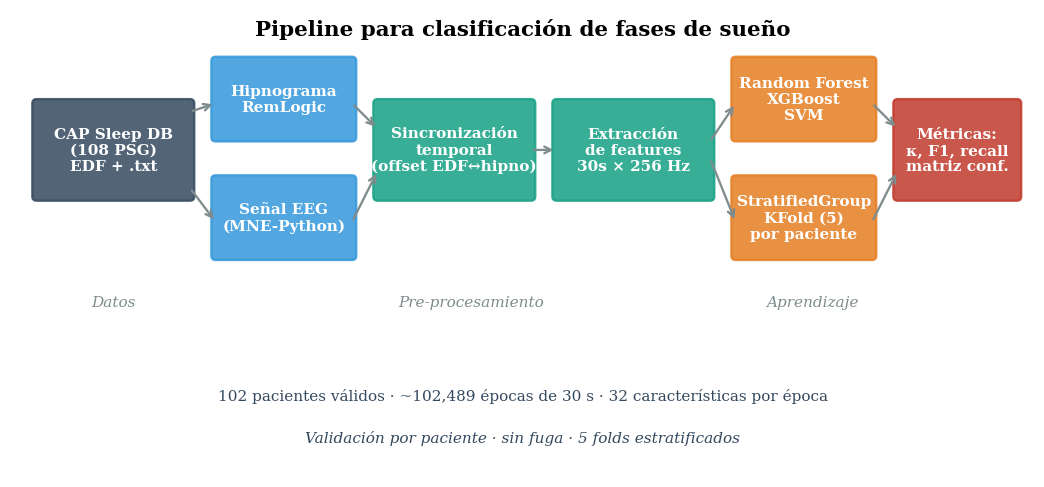

In [2]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.set_xlim(0, 12); ax.set_ylim(0, 5.5)
ax.axis('off')

# Definición de cajas: (x, y, ancho, alto, texto, color)
cajas = [
    (0.3, 3.3, 1.8, 1.1, 'CAP Sleep DB\n(108 PSG)\nEDF + .txt', '#34495E'),
    (2.4, 4.0, 1.6, 0.9, 'Hipnograma\nRemLogic', '#3498DB'),
    (2.4, 2.6, 1.6, 0.9, 'Señal EEG\n(MNE-Python)', '#3498DB'),
    (4.3, 3.3, 1.8, 1.1, 'Sincronización\ntemporal\n(offset EDF↔hipno)', '#16A085'),
    (6.4, 3.3, 1.8, 1.1, 'Extracción\nde features\n30s × 256 Hz', '#16A085'),
    (8.5, 4.0, 1.6, 0.9, 'Random Forest\nXGBoost\nSVM', '#E67E22'),
    (8.5, 2.6, 1.6, 0.9, 'StratifiedGroup\nKFold (5)\npor paciente', '#E67E22'),
    (10.4, 3.3, 1.4, 1.1, 'Métricas:\nκ, F1, recall\nmatriz conf.', '#C0392B'),
]

for x, y, w, h, txt, col in cajas:
    box = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.05',
                         linewidth=1.5, edgecolor=col, facecolor=col, alpha=0.85)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, txt, ha='center', va='center',
            color='white', fontsize=10, fontweight='bold')

# Flechas
flechas = [
    ((2.1, 4.3), (2.4, 4.4)),   # DB -> Hipno
    ((2.1, 3.4), (2.4, 3.0)),   # DB -> Señal
    ((4.0, 4.4), (4.3, 4.1)),   # Hipno -> Sync
    ((4.0, 3.0), (4.3, 3.6)),   # Señal -> Sync
    ((6.1, 3.85), (6.4, 3.85)), # Sync -> Extr
    ((8.2, 3.95), (8.5, 4.4)),  # Extr -> Modelos
    ((8.2, 3.75), (8.5, 3.0)),  # Extr -> CV
    ((10.1, 4.4), (10.4, 4.1)), # Modelos -> Métricas
    ((10.1, 3.0), (10.4, 3.6)), # CV -> Métricas
]
for (x1, y1), (x2, y2) in flechas:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#7F8C8D'))

# Título y secciones
ax.text(6, 5.2, 'Pipeline para clasificación de fases de sueño',
        ha='center', fontsize=14, fontweight='bold')

# Etiquetas de bloques inferiores
ax.text(1.2, 2.0, 'Datos', ha='center', fontsize=10, style='italic', color='#7F8C8D')
ax.text(5.4, 2.0, 'Pre-procesamiento', ha='center', fontsize=10, style='italic', color='#7F8C8D')
ax.text(9.4, 2.0, 'Aprendizaje', ha='center', fontsize=10, style='italic', color='#7F8C8D')

# Detalle bajo el pipeline
ax.text(6, 0.9, '102 pacientes válidos · ~102,489 épocas de 30 s · 32 características por época',
        ha='center', fontsize=10, color='#34495E')
ax.text(6, 0.4, 'Validación por paciente · sin fuga · 5 folds estratificados',
        ha='center', fontsize=10, color='#34495E', style='italic')

ax.set_title('')
guardar_figura(fig, 'pipeline', 1)
plt.show()

## Figura 2 — Ejemplo de hipnograma

Hipnogramas de un paciente representativo de cada subgrupo diagnóstico,
mostrando la estructura cíclica del sueño y las diferencias
arquitectónicas entre patologías.

Hipnograma consolidado: (105382, 9), pacientes=105
Representantes: {'Normal': 'n1', 'SDB / apnea': 'sdb4', 'RBD': 'rbd8', 'Insomnio': 'ins1'}
  ✓ Figura 2: fig02_hipnogramas_representativos.{png,pdf}


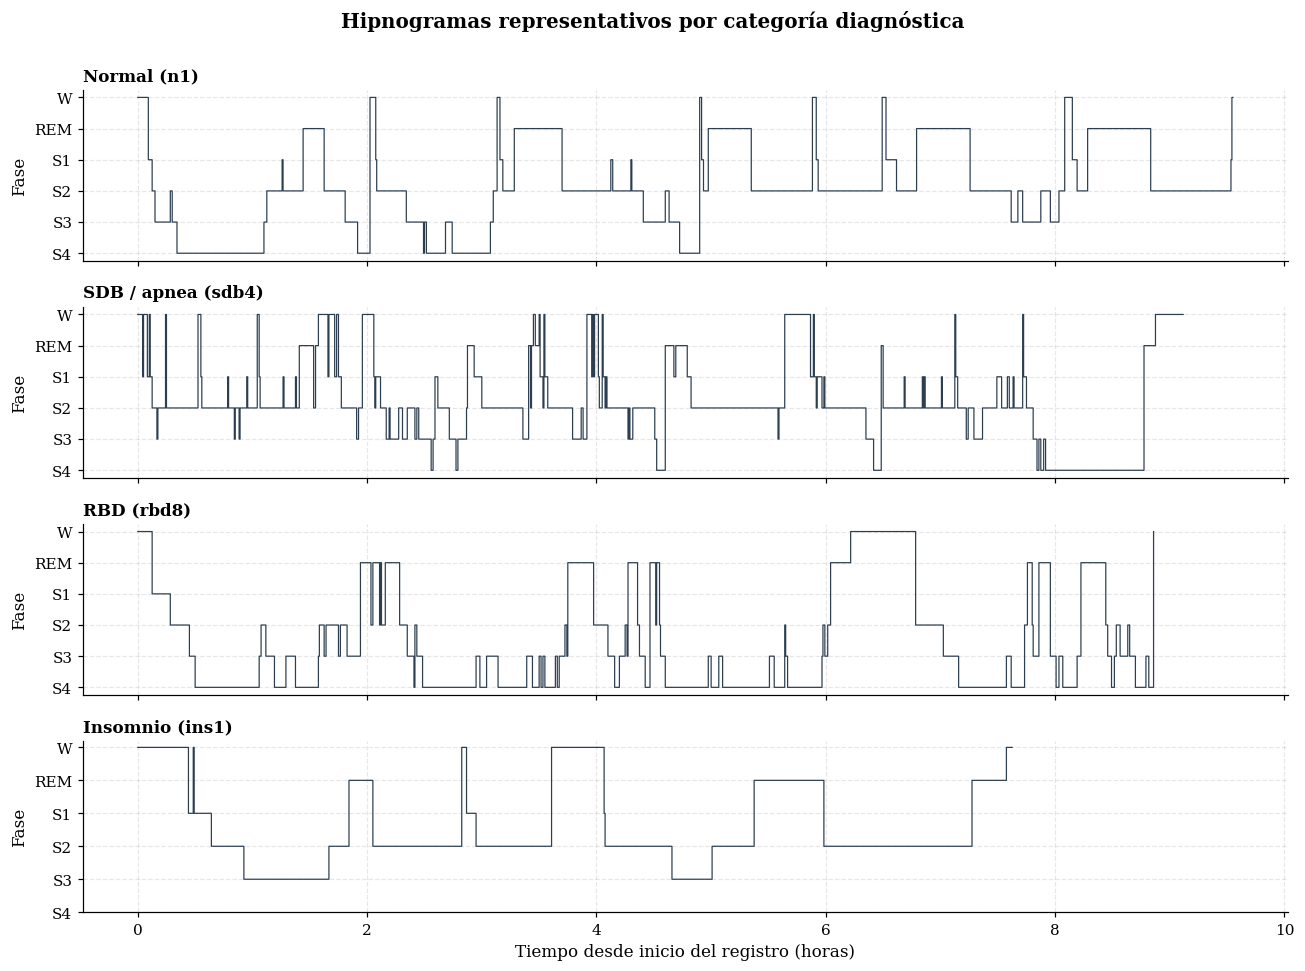

In [3]:
hip_cons = pd.read_csv(HYPNO_DIR / 'hipnogramas_consolidado.csv')
print(f'Hipnograma consolidado: {hip_cons.shape}, pacientes={hip_cons["patient"].nunique()}')

# Seleccionar un paciente representativo de cada grupo (que tengamos)
representantes = {}
for prefijo, grupo in [('n1','Normal'),('sdb4','SDB / apnea'),
                       ('rbd8','RBD'),('ins1','Insomnio')]:
    if prefijo in hip_cons['patient'].values:
        representantes[grupo] = prefijo

print(f'Representantes: {representantes}')

ORDEN_HIPNO = ['W', 'REM', 'S1', 'S2', 'S3', 'S4']
stage_to_y = {s: i for i, s in enumerate(ORDEN_HIPNO)}

fig, axes = plt.subplots(len(representantes), 1,
                         figsize=(12, 2.2 * len(representantes)),
                         sharex=True)
if len(representantes) == 1: axes = [axes]

for ax, (grupo, paciente) in zip(axes, representantes.items()):
    h = hip_cons[hip_cons['patient'] == paciente]
    horas = h['onset_s'] / 3600
    y = h['stage'].map(stage_to_y)
    ax.step(horas, y, where='post', linewidth=0.8, color='#2C3E50')
    ax.set_yticks(range(len(ORDEN_HIPNO)))
    ax.set_yticklabels(ORDEN_HIPNO)
    ax.invert_yaxis()
    ax.set_ylabel('Fase')
    ax.set_title(f'{grupo} ({paciente})', loc='left', fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Tiempo desde inicio del registro (horas)')
plt.suptitle('Hipnogramas representativos por categoría diagnóstica',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
guardar_figura(fig, 'hipnogramas_representativos', 2)
plt.show()

## Figura 3 — Distribución de fases en el dataset

Composición del dataset completo: número de épocas por fase y porcentaje
respecto al total. Documenta el desbalance fisiológico esperado.

  ✓ Figura 3: fig03_distribucion_fases.{png,pdf}


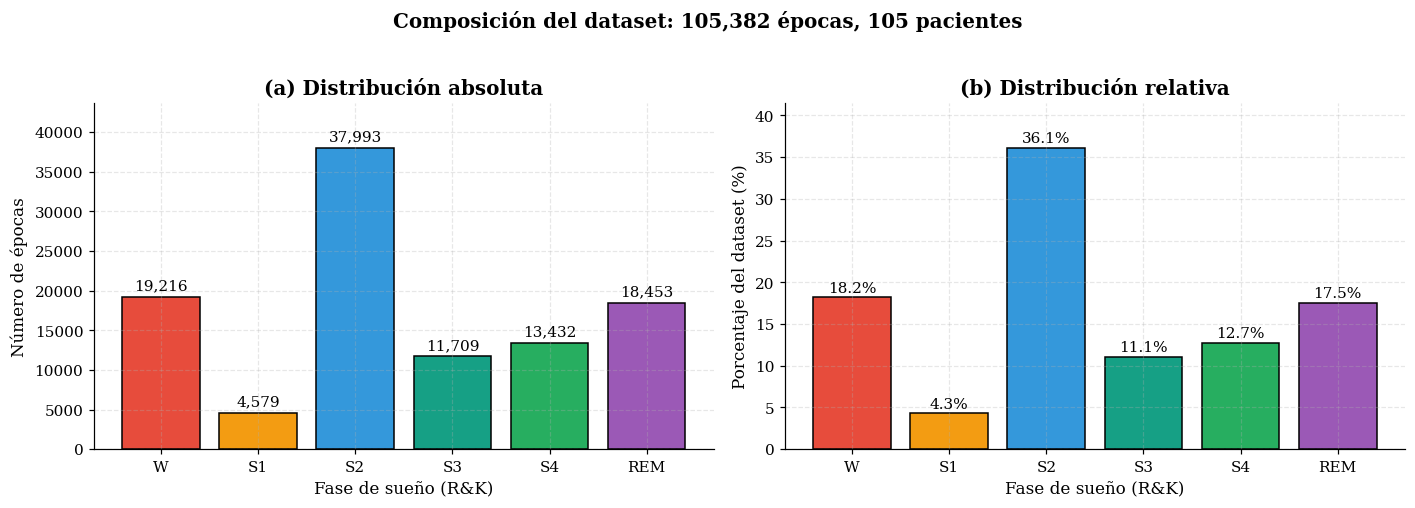

In [4]:
# Reconstruir distribución desde el consolidado
dist = hip_cons['stage'].value_counts().reindex(CLASES_RK)
total = dist.sum()
pct = (dist / total * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel A: barras absolutas
colores = [PALETA_FASES[s] for s in CLASES_RK]
bars = axes[0].bar(CLASES_RK, dist.values, color=colores,
                    edgecolor='black', linewidth=1)
for bar, n in zip(bars, dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
                 f'{int(n):,}', ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel('Número de épocas')
axes[0].set_xlabel('Fase de sueño (R&K)')
axes[0].set_title('(a) Distribución absoluta')
axes[0].set_ylim(0, dist.max() * 1.15)

# Panel B: porcentajes con anotación
bars = axes[1].bar(CLASES_RK, pct.values, color=colores,
                    edgecolor='black', linewidth=1)
for bar, p in zip(bars, pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{p:.1f}%', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Porcentaje del dataset (%)')
axes[1].set_xlabel('Fase de sueño (R&K)')
axes[1].set_title('(b) Distribución relativa')
axes[1].set_ylim(0, max(pct.values) * 1.15)

plt.suptitle(f'Composición del dataset: {total:,} épocas, '
             f'{hip_cons["patient"].nunique()} pacientes',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
guardar_figura(fig, 'distribucion_fases', 3)
plt.show()

## Figura 4 — Heterogeneidad de frecuencias de muestreo

Documenta la heterogeneidad técnica del dataset (justifica el resampleo
a 256 Hz en el pipeline). Información tomada de los logs del notebook 1.

  ✓ Figura 4: fig04_frecuencias_muestreo.{png,pdf}


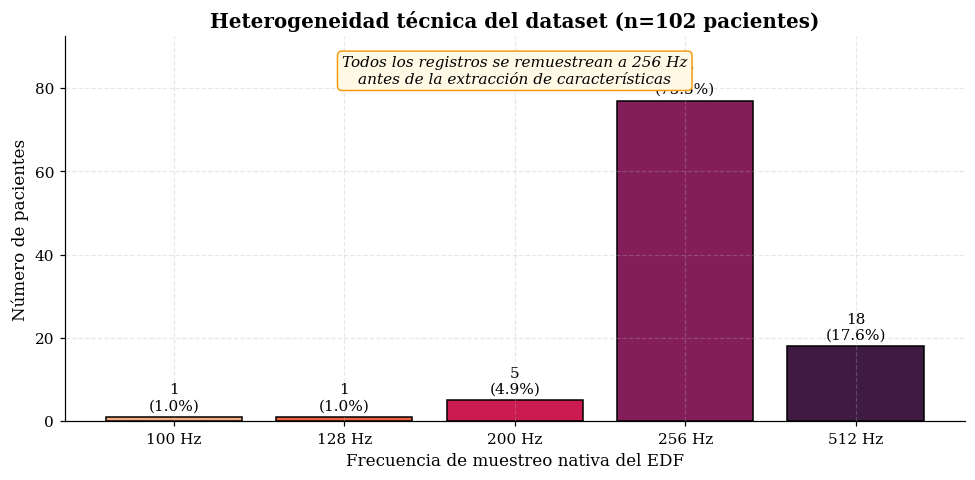

In [5]:
# Recuento manual de fs basado en lo observado durante extracción.
# Si tienes los EDF disponibles, puedes regenerar esto leyendo
# meas_info['sfreq'] de cada uno.

fs_observadas = {
    256:  77,   # mayoría de pacientes
    512:  18,
    200:  5,
    100:  1,
    128:  1,
}
# Ajusta a tu cifra real si la tienes (debe sumar ~102)

total_pacientes = sum(fs_observadas.values())
fig, ax = plt.subplots(figsize=(9, 4.5))

fs_sorted = sorted(fs_observadas.items())
xs = [f'{fs} Hz' for fs, _ in fs_sorted]
ys = [n for _, n in fs_sorted]
colores_fs = sns.color_palette('rocket_r', len(xs))
bars = ax.bar(xs, ys, color=colores_fs, edgecolor='black', linewidth=1)
for bar, n in zip(bars, ys):
    pct = 100 * n / total_pacientes
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{n}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Frecuencia de muestreo nativa del EDF')
ax.set_ylabel('Número de pacientes')
ax.set_title(f'Heterogeneidad técnica del dataset (n={total_pacientes} pacientes)')
ax.set_ylim(0, max(ys) * 1.2)

# Anotación
ax.axhline(0, color='black', linewidth=0.5)
ax.annotate('Todos los registros se remuestrean a 256 Hz\nantes de la extracción de características',
            xy=(0.5, 0.95), xycoords='axes fraction', ha='center', va='top',
            fontsize=10, style='italic',
            bbox=dict(boxstyle='round', facecolor='#FFF9E5', edgecolor='#F39C12'))

plt.tight_layout()
guardar_figura(fig, 'frecuencias_muestreo', 4)
plt.show()

## Figura 5 — Perfil espectral por fase (validación fisiológica)

Potencia relativa media por banda EEG y fase de sueño. Demuestra que las
características capturan la fisiología esperada: delta crece W→S4, beta
cae, sigma máximo en sueño ligero, theta dominante en REM.

Dataset por época: (102489, 36)
  ✓ Figura 5: fig05_perfil_espectral_fases.{png,pdf}


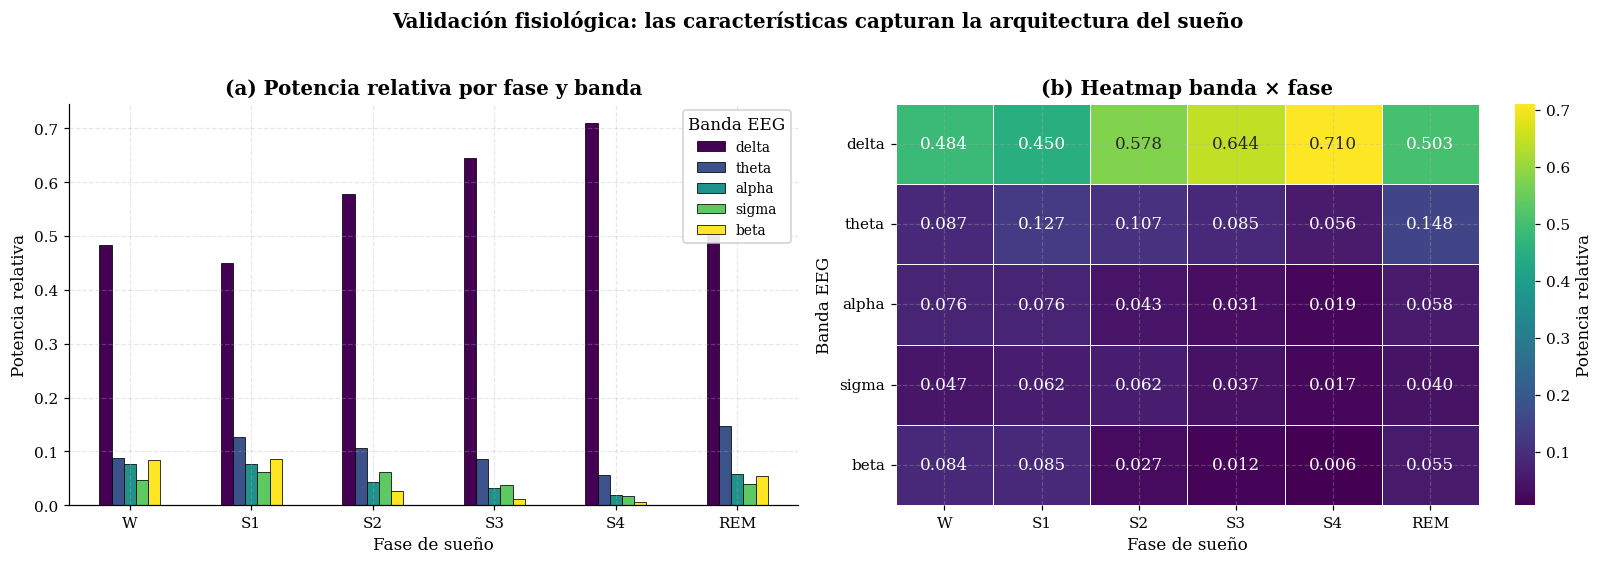


Perfil numérico:
       delta  theta  alpha  sigma   beta
stage                                   
W      0.484  0.087  0.076  0.047  0.084
S1     0.450  0.127  0.076  0.062  0.085
S2     0.578  0.107  0.043  0.062  0.027
S3     0.644  0.085  0.031  0.037  0.012
S4     0.710  0.056  0.019  0.017  0.006
REM    0.503  0.148  0.058  0.040  0.055


In [6]:
df_feat = pd.read_csv(FEATURES_DIR / 'caracteristicas_fases_30s.csv')
# Colapsar por época promediando canales
META = ['patient','channel','epoch_idx','onset_s','stage']
FEAT = [c for c in df_feat.columns if c not in META]
df_epoca = df_feat.groupby(['patient','epoch_idx','onset_s','stage'],
                            as_index=False)[FEAT].mean()
print(f'Dataset por época: {df_epoca.shape}')

# Promedio por fase de las potencias relativas
bandas_rel = ['pot_delta_rel','pot_theta_rel','pot_alpha_rel',
              'pot_sigma_rel','pot_beta_rel']
perfil = df_epoca.groupby('stage')[bandas_rel].mean().reindex(CLASES_RK)
perfil.columns = ['delta','theta','alpha','sigma','beta']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel A: barras agrupadas
perfil.plot(kind='bar', ax=axes[0], colormap='viridis',
            edgecolor='black', linewidth=0.5)
axes[0].set_title('(a) Potencia relativa por fase y banda')
axes[0].set_ylabel('Potencia relativa')
axes[0].set_xlabel('Fase de sueño')
axes[0].legend(title='Banda EEG', loc='upper right', fontsize=9)
plt.setp(axes[0].get_xticklabels(), rotation=0)

# Panel B: heatmap del mismo dato (lectura alternativa)
sns.heatmap(perfil.T, annot=True, fmt='.3f', cmap='viridis',
            cbar_kws={'label':'Potencia relativa'}, ax=axes[1],
            linewidths=0.5, linecolor='white')
axes[1].set_title('(b) Heatmap banda × fase')
axes[1].set_xlabel('Fase de sueño')
axes[1].set_ylabel('Banda EEG')
plt.setp(axes[1].get_yticklabels(), rotation=0)

plt.suptitle('Validación fisiológica: las características capturan la arquitectura del sueño',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
guardar_figura(fig, 'perfil_espectral_fases', 5)
plt.show()

print('\nPerfil numérico:')
print(perfil.round(3).to_string())

## Figura 6 — Boxplots de características clave por fase

Distribución de las 4 características más informativas por fase. Muestra
visualmente la discriminación y los outliers fisiológicos.

C:\Users\Gumi\AppData\Local\Temp\ipykernel_38160\1943001767.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos, x='stage', y=col, order=CLASES_RK,
C:\Users\Gumi\AppData\Local\Temp\ipykernel_38160\1943001767.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos, x='stage', y=col, order=CLASES_RK,
C:\Users\Gumi\AppData\Local\Temp\ipykernel_38160\1943001767.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos, x='stage', y=col, order=CLASES_RK,
C:\Users\Gumi\AppData\Local\Temp\ipykernel_38160\1943001767.py:16: 

  ✓ Figura 6: fig06_boxplots_features.{png,pdf}


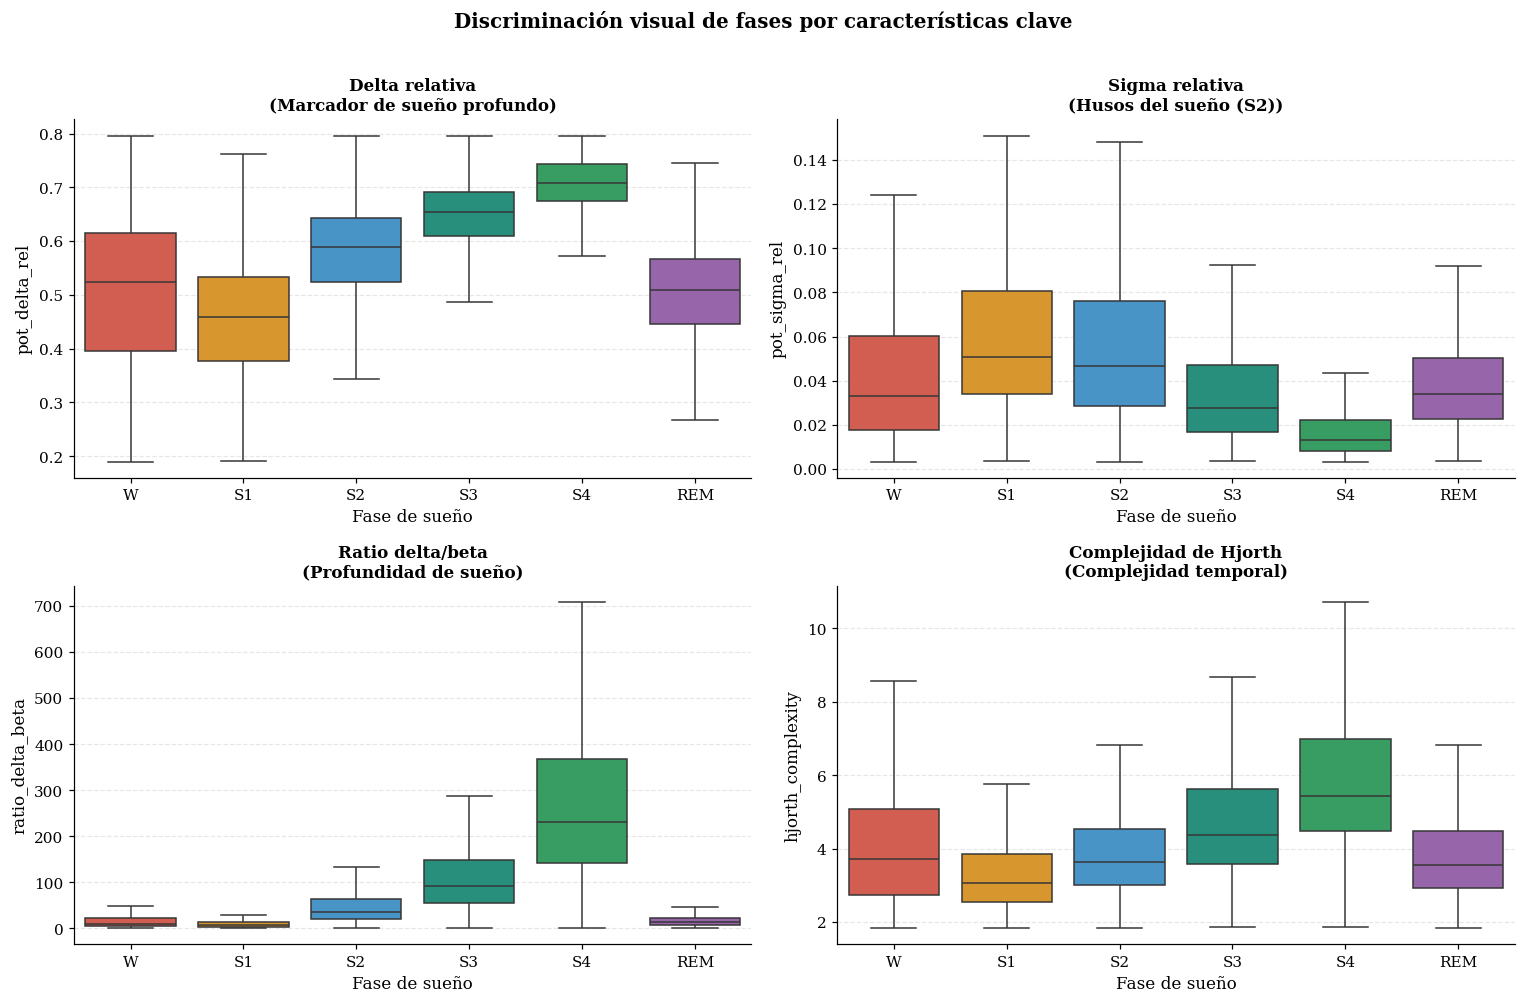

In [7]:
caracteristicas_clave = [
    ('pot_delta_rel',     'Delta relativa',        'Marcador de sueño profundo'),
    ('pot_sigma_rel',     'Sigma relativa',        'Husos del sueño (S2)'),
    ('ratio_delta_beta',  'Ratio delta/beta',      'Profundidad de sueño'),
    ('hjorth_complexity', 'Complejidad de Hjorth', 'Complejidad temporal'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (col, titulo, sub) in zip(axes.flat, caracteristicas_clave):
    if col not in df_epoca.columns:
        ax.set_visible(False); continue
    # Aplicar clip al 1-99% para evitar que outliers extremos dominen
    valores = df_epoca[col]
    q1, q99 = valores.quantile([0.01, 0.99])
    datos = df_epoca[(valores >= q1) & (valores <= q99)]
    sns.boxplot(data=datos, x='stage', y=col, order=CLASES_RK,
                palette=[PALETA_FASES[s] for s in CLASES_RK],
                ax=ax, showfliers=False, linewidth=1)
    ax.set_title(f'{titulo}\n({sub})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Fase de sueño')
    ax.set_ylabel(col)

plt.suptitle('Discriminación visual de fases por características clave',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
guardar_figura(fig, 'boxplots_features', 6)
plt.show()

## Figura 7 — Comparación de modelos

Métricas de los 3 modelos (RF, XGBoost, SVM) en ambos esquemas (R&K y
AASM). Incluye barras de error (std entre folds) y la línea de referencia
del acuerdo inter-experto humano (κ≈0.76).

  ✓ Figura 7: fig07_comparacion_modelos.{png,pdf}


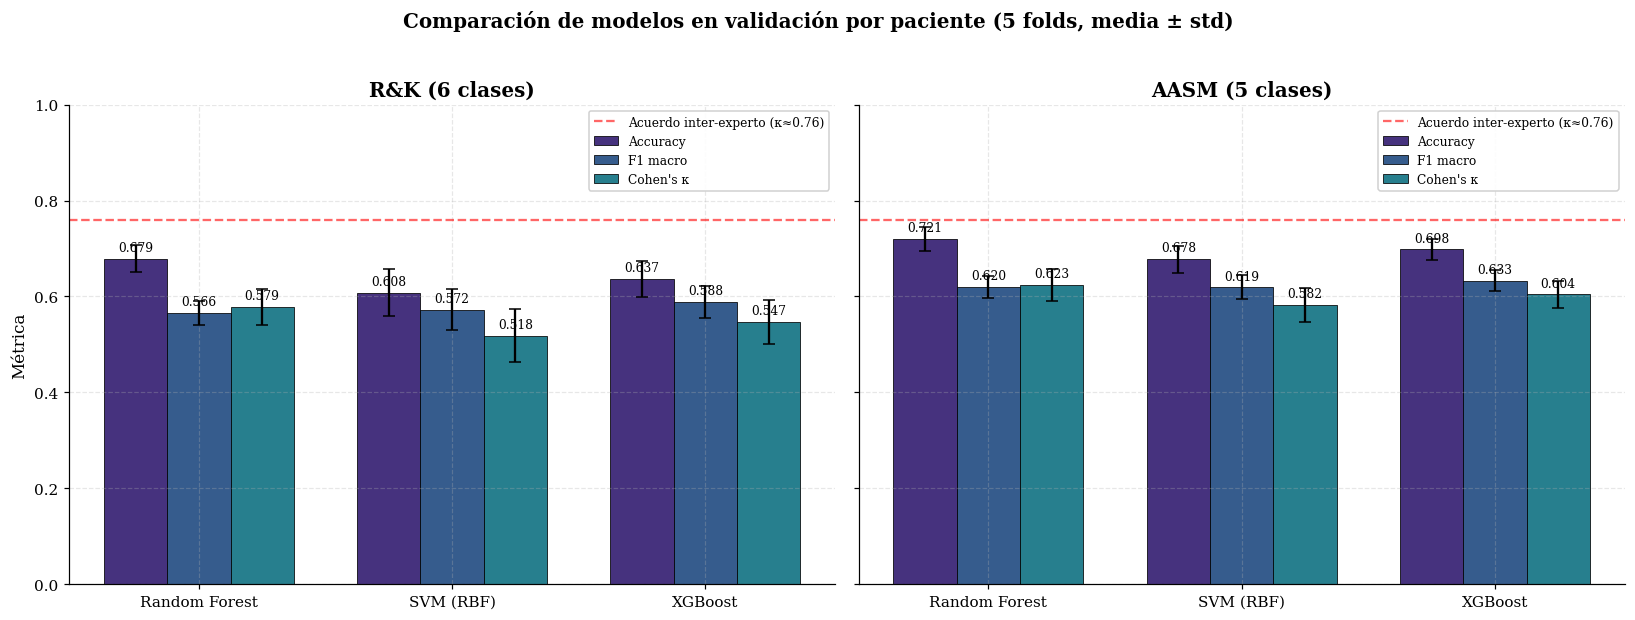

In [8]:
df_rk_metrics = pd.read_csv(RESULTS_DIR / 'metricas_rk.csv')
df_aasm_metrics = pd.read_csv(RESULTS_DIR / 'metricas_aasm.csv')

# Agregar
agg_rk = df_rk_metrics.groupby('modelo')[['accuracy','f1_macro','kappa']].agg(['mean','std'])
agg_aasm = df_aasm_metrics.groupby('modelo')[['accuracy','f1_macro','kappa']].agg(['mean','std'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

for ax, (esquema, agg) in zip(axes, [('R&K (6 clases)', agg_rk),
                                       ('AASM (5 clases)', agg_aasm)]):
    modelos = agg.index.tolist()
    metricas = ['accuracy','f1_macro','kappa']
    nombres_metricas = ['Accuracy', 'F1 macro', "Cohen's κ"]
    x = np.arange(len(modelos))
    width = 0.25
    for i, (m, nm) in enumerate(zip(metricas, nombres_metricas)):
        medias = agg[(m,'mean')].values
        stds = agg[(m,'std')].values
        bars = ax.bar(x + i*width - width, medias, width,
                       yerr=stds, capsize=4, label=nm,
                       edgecolor='black', linewidth=0.5)
        for bar, val in zip(bars, medias):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    # Línea de referencia
    ax.axhline(0.76, color='red', linestyle='--', alpha=0.6, linewidth=1.5,
                label='Acuerdo inter-experto (κ≈0.76)')
    ax.set_xticks(x)
    ax.set_xticklabels(modelos)
    ax.set_title(esquema)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Métrica' if esquema.startswith('R&K') else '')
    ax.legend(loc='upper right', fontsize=8, ncol=1)

plt.suptitle('Comparación de modelos en validación por paciente (5 folds, ' +
             'media ± std)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
guardar_figura(fig, 'comparacion_modelos', 7)
plt.show()

## Figura 8 — Matrices de confusión

Matrices del mejor modelo (Random Forest) en ambos esquemas, normalizadas
por fila. Muestra el patrón de errores característico de sleep staging.

  ✓ Figura 8: fig08_matrices_confusion_rf.{png,pdf}


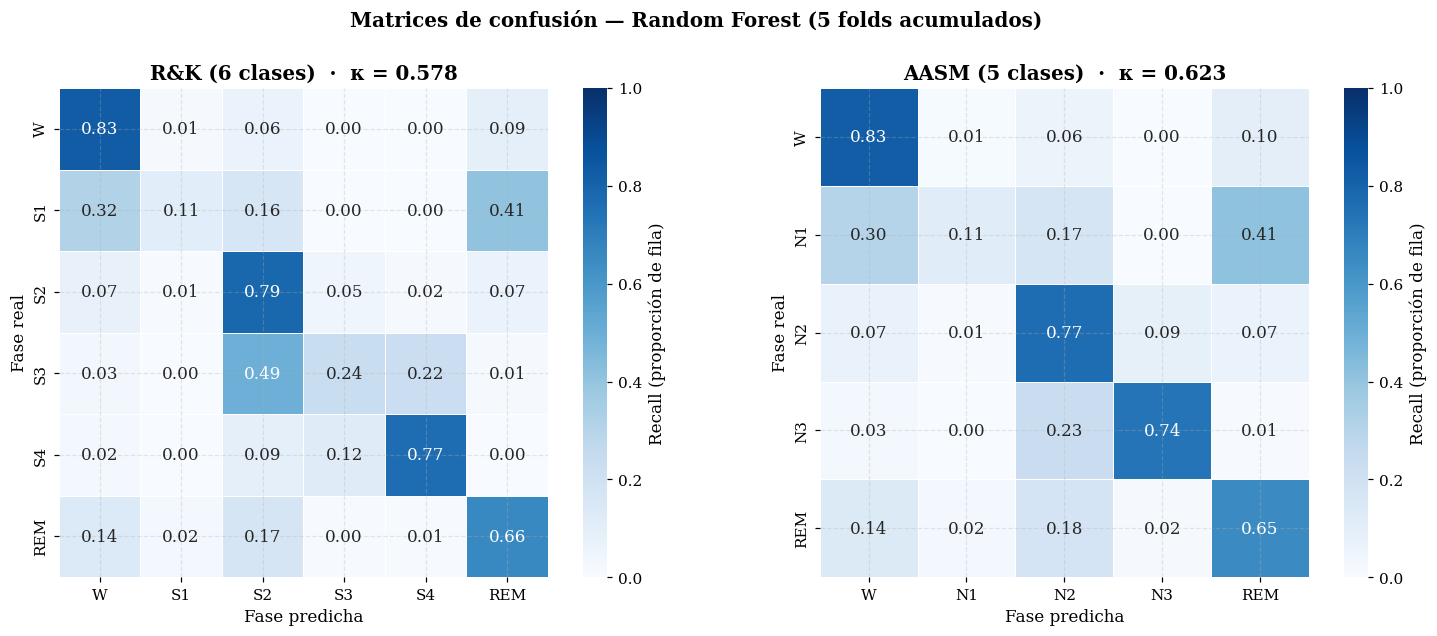

In [9]:
from sklearn.metrics import cohen_kappa_score

def cargar_matriz(esquema, modelo_slug):
    '''Carga matriz de confusión guardada por el notebook 2.'''
    f = RESULTS_DIR / f'cm_{esquema}_{modelo_slug}.csv'
    return np.loadtxt(f, delimiter=',', skiprows=1, dtype=int)

cm_rk = cargar_matriz('rk', 'random_forest')
cm_aasm = cargar_matriz('aasm', 'random_forest')

def kappa_desde_cm(cm, clases):
    y_true = np.concatenate([[clases[i]] * cm[i].sum() for i in range(len(clases))])
    y_pred = np.concatenate([[clases[j]] * cm[i,j]
                             for i in range(len(clases))
                             for j in range(len(clases))])
    return cohen_kappa_score(y_true, y_pred, labels=clases)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, cm, clases, titulo in [(axes[0], cm_rk, CLASES_RK, 'R&K (6 clases)'),
                                 (axes[1], cm_aasm, CLASES_AASM, 'AASM (5 clases)')]:
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=clases, yticklabels=clases,
                vmin=0, vmax=1, cbar_kws={'label':'Recall (proporción de fila)'},
                ax=ax, square=True, linewidths=0.5, linecolor='white')
    kpa = kappa_desde_cm(cm, clases)
    ax.set_title(f'{titulo}  ·  κ = {kpa:.3f}')
    ax.set_xlabel('Fase predicha')
    ax.set_ylabel('Fase real')

plt.suptitle('Matrices de confusión — Random Forest (5 folds acumulados)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
guardar_figura(fig, 'matrices_confusion_rf', 8)
plt.show()

## Figura 9 — Recall por fase × modelo

Compara qué tan bien recupera cada modelo cada clase. Resalta el problema
universal con la fase N1/S1.

  ✓ Figura 9: fig09_recall_por_fase_modelo.{png,pdf}


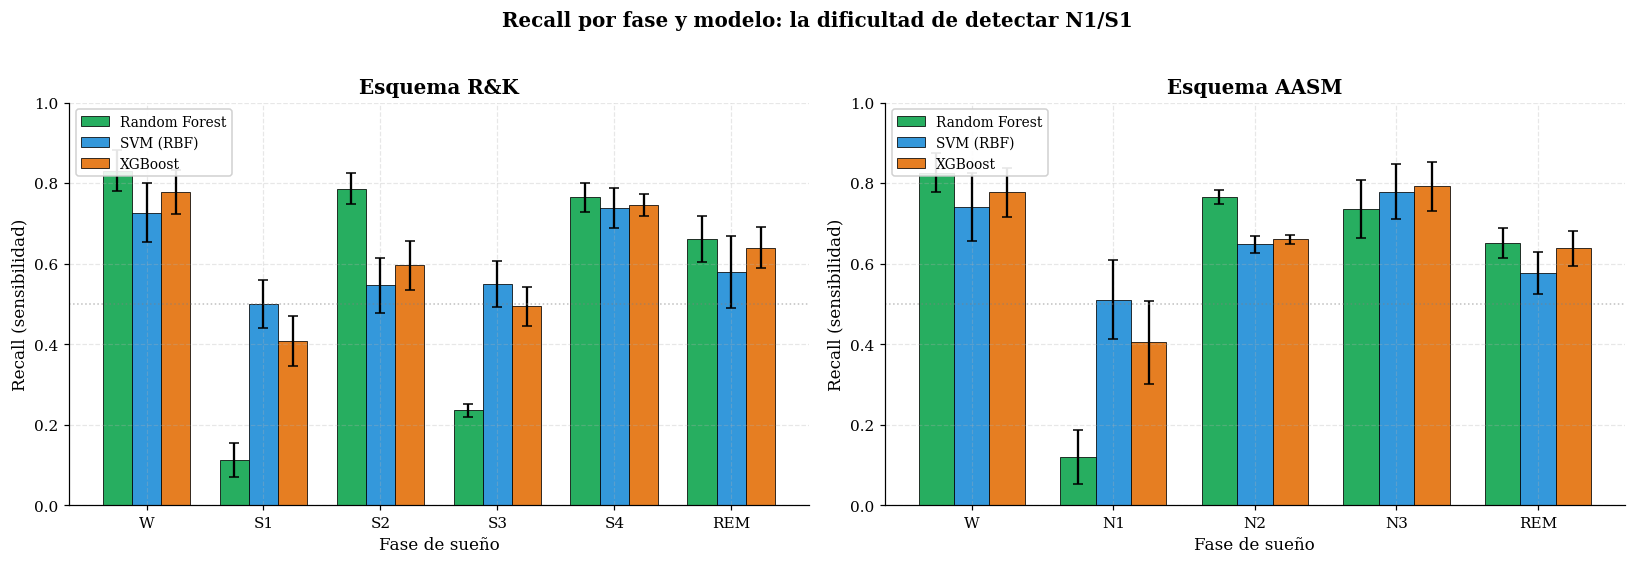

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (df_metr, clases, esquema) in zip(
    axes,
    [(df_rk_metrics, CLASES_RK, 'R&K'),
     (df_aasm_metrics, CLASES_AASM, 'AASM')]
):
    cols_recall = [f'recall_{c}' for c in clases]
    agg = df_metr.groupby('modelo')[cols_recall].agg(['mean','std'])
    modelos = agg.index.tolist()
    x = np.arange(len(clases))
    width = 0.25
    for i, m in enumerate(modelos):
        medias = [agg[(c,'mean')][m] for c in cols_recall]
        stds = [agg[(c,'std')][m] for c in cols_recall]
        offset = (i - (len(modelos)-1)/2) * width
        ax.bar(x + offset, medias, width, yerr=stds, capsize=3,
                label=m, color=PALETA_MODELOS.get(m, '#888'),
                edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(clases)
    ax.set_xlabel('Fase de sueño')
    ax.set_ylabel('Recall (sensibilidad)')
    ax.set_title(f'Esquema {esquema}')
    ax.set_ylim(0, 1.0)
    ax.legend(loc='upper left', fontsize=9)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.suptitle('Recall por fase y modelo: la dificultad de detectar N1/S1',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
guardar_figura(fig, 'recall_por_fase_modelo', 9)
plt.show()

## Figura 10 — Importancia de características (Random Forest)

Top 15 características por importancia, agrupadas visualmente por familia
(temporal / espectral / Hjorth / entropía) para mostrar de dónde proviene
la información discriminante.


Importancia total acumulada por familia (top 15):
              sum  count
familia                 
Entropía   0.0627      2
Espectral  0.4191      9
Hjorth     0.0520      1
Temporal   0.1299      3
  ✓ Figura 10: fig10_importancia_features.{png,pdf}


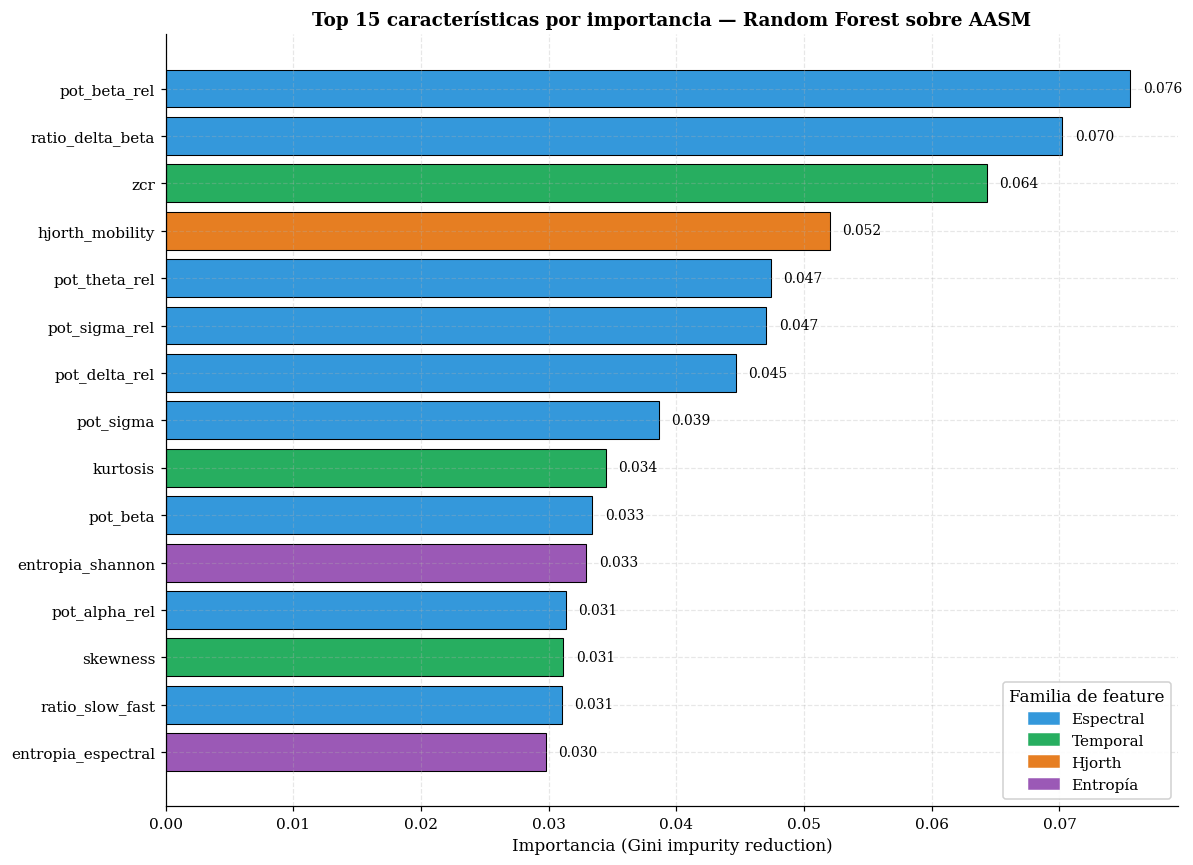

In [11]:
imp = pd.read_csv(RESULTS_DIR / 'importancia_features.csv')
top15 = imp.head(15).reset_index(drop=True)

# Clasificar cada feature por familia para colorear
def familia(nombre):
    if nombre.startswith('pot_') or 'freq' in nombre or 'ratio' in nombre:
        return ('Espectral', '#3498DB')
    if nombre.startswith('hjorth'):
        return ('Hjorth', '#E67E22')
    if 'entropia' in nombre:
        return ('Entropía', '#9B59B6')
    return ('Temporal', '#27AE60')

top15['familia'] = top15['feature'].apply(lambda f: familia(f)[0])
top15['color'] = top15['feature'].apply(lambda f: familia(f)[1])

fig, ax = plt.subplots(figsize=(11, 8))
# Invertir para que el más importante esté arriba
y_pos = np.arange(len(top15))[::-1]
bars = ax.barh(y_pos, top15['importance'].values,
                color=top15['color'].values,
                edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, top15['importance'].values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_yticks(y_pos)
ax.set_yticklabels(top15['feature'].values)
ax.set_xlabel('Importancia (Gini impurity reduction)')
ax.set_title('Top 15 características por importancia — Random Forest sobre AASM',
             fontsize=12, fontweight='bold')

# Leyenda de familias
familias_unicas = top15[['familia','color']].drop_duplicates()
handles = [mpatches.Patch(color=row['color'], label=row['familia'])
           for _, row in familias_unicas.iterrows()]
ax.legend(handles=handles, loc='lower right', title='Familia de feature')

# Resumen estadístico por familia
print('\nImportancia total acumulada por familia (top 15):')
print(top15.groupby('familia')['importance'].agg(['sum','count']).round(4))

plt.tight_layout()
guardar_figura(fig, 'importancia_features', 10)
plt.show()

## Figura 11 — Comparación con literatura

Posiciona nuestros resultados (κ ≈ 0.62) en el contexto de trabajos
publicados en sleep staging con la CAP DB o datasets equivalentes.

  ✓ Figura 11: fig11_comparacion_literatura.{png,pdf}


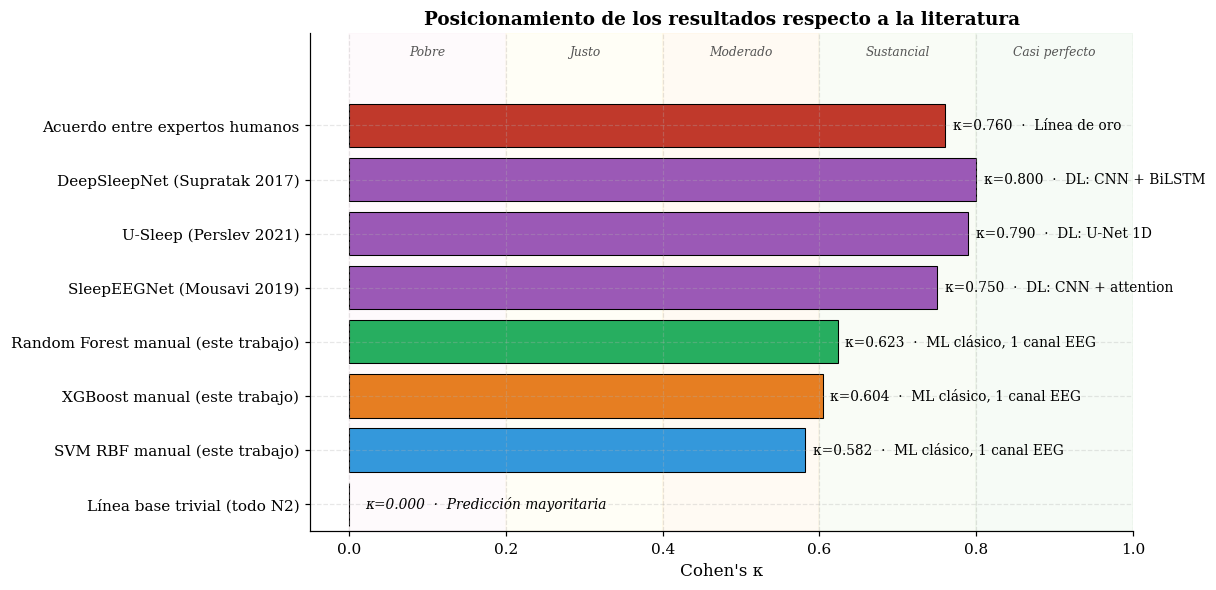

In [12]:
# Estudios de referencia (valores aproximados de la literatura).
# Ajusta si tienes citas más específicas.
referencias = [
    ('Acuerdo entre expertos humanos', 0.76, 'Línea de oro', '#C0392B'),
    ('DeepSleepNet (Supratak 2017)', 0.80, 'DL: CNN + BiLSTM', '#9B59B6'),
    ('U-Sleep (Perslev 2021)', 0.79, 'DL: U-Net 1D', '#9B59B6'),
    ('SleepEEGNet (Mousavi 2019)', 0.75, 'DL: CNN + attention', '#9B59B6'),
    ('Random Forest manual (este trabajo)', 0.623, 'ML clásico, 1 canal EEG', '#27AE60'),
    ('XGBoost manual (este trabajo)', 0.604, 'ML clásico, 1 canal EEG', '#E67E22'),
    ('SVM RBF manual (este trabajo)', 0.582, 'ML clásico, 1 canal EEG', '#3498DB'),
    ('Línea base trivial (todo N2)', 0.0, 'Predicción mayoritaria', '#7F8C8D'),
]

fig, ax = plt.subplots(figsize=(11, 5.5))
y_pos = np.arange(len(referencias))
nombres = [r[0] for r in referencias]
valores = [r[1] for r in referencias]
descripciones = [r[2] for r in referencias]
colores_ref = [r[3] for r in referencias]

bars = ax.barh(y_pos[::-1], valores, color=colores_ref,
                edgecolor='black', linewidth=0.7)
for bar, val, desc in zip(bars, valores, descripciones):
    if val > 0:
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'κ={val:.3f}  ·  {desc}', va='center', fontsize=9)
    else:
        ax.text(0.02, bar.get_y() + bar.get_height()/2,
                f'κ={val:.3f}  ·  {desc}', va='center', fontsize=9, style='italic')

ax.set_yticks(y_pos[::-1])
ax.set_yticklabels(nombres)
ax.set_xlabel("Cohen's κ")
ax.set_xlim(-0.05, 1.0)
ax.set_title('Posicionamiento de los resultados respecto a la literatura',
             fontsize=12, fontweight='bold')

# Anotaciones de regiones interpretativas (Landis & Koch 1977)
regiones = [(0.0, 0.20, 'Pobre', '#FCE4EC'),
            (0.20, 0.40, 'Justo', '#FFF9C4'),
            (0.40, 0.60, 'Moderado', '#FFE0B2'),
            (0.60, 0.80, 'Sustancial', '#DCEDC8'),
            (0.80, 1.00, 'Casi perfecto', '#C8E6C9')]
for lo, hi, etiqueta, color in regiones:
    ax.axvspan(lo, hi, alpha=0.15, color=color, zorder=0)
    ax.text((lo+hi)/2, len(referencias) + 0.3, etiqueta,
            ha='center', fontsize=8, style='italic', color='#555')

ax.set_ylim(-0.5, len(referencias) + 0.7)
plt.tight_layout()
guardar_figura(fig, 'comparacion_literatura', 11)
plt.show()

## Resumen final

In [13]:
# Inventario de figuras generadas
figuras_generadas = sorted(FIG_DIR.glob('fig*.png'))
print(f'\n📊 Figuras generadas en {FIG_DIR.resolve()}:\n')
for f in figuras_generadas:
    pdf = f.with_suffix('.pdf')
    tam_png = f.stat().st_size / 1024
    tam_pdf = pdf.stat().st_size / 1024 if pdf.exists() else 0
    print(f'  {f.name:<45} PNG: {tam_png:>6.1f} KB  ·  PDF: {tam_pdf:>6.1f} KB')

print(f'\nTotal: {len(figuras_generadas)} figuras × 2 formatos = {2*len(figuras_generadas)} archivos')
print(f'\nPara LaTeX, usa los .pdf (vectoriales).')
print(f'Para Word/preview, usa los .png (300 dpi).')


📊 Figuras generadas en D:\Repos\RAHBFDP-2026\data\figuras_articulo:

  fig01_pipeline.png                            PNG:  254.3 KB  ·  PDF:   43.1 KB
  fig02_hipnogramas_representativos.png         PNG:  237.4 KB  ·  PDF:   29.4 KB
  fig03_distribucion_fases.png                  PNG:  223.7 KB  ·  PDF:   30.7 KB
  fig04_frecuencias_muestreo.png                PNG:  152.2 KB  ·  PDF:   32.9 KB
  fig05_perfil_espectral_fases.png              PNG:  313.1 KB  ·  PDF:   33.2 KB
  fig06_boxplots_features.png                   PNG:  288.4 KB  ·  PDF:   32.6 KB
  fig07_comparacion_modelos.png                 PNG:  202.0 KB  ·  PDF:   31.4 KB
  fig08_matrices_confusion_rf.png               PNG:  358.5 KB  ·  PDF:   35.8 KB
  fig09_recall_por_fase_modelo.png              PNG:  161.3 KB  ·  PDF:   28.6 KB
  fig10_importancia_features.png                PNG:  263.3 KB  ·  PDF:   27.2 KB
  fig11_comparacion_literatura.png              PNG:  292.8 KB  ·  PDF:   40.4 KB

Total: 11 figuras × 2 forma

### Cómo usar estas figuras en el artículo

**En LaTeX:**

```latex
\begin{figure}[!t]
  \centering
  \includegraphics[width=0.95\linewidth]{figuras_articulo/fig07_comparacion_modelos.pdf}
  \caption{Comparación de modelos en validación por paciente (5 folds).
  Las barras de error muestran la desviación estándar entre folds.
  La línea roja punteada indica el acuerdo inter-experto humano
  reportado en la literatura ($\kappa \approx 0.76$).}
  \label{fig:comparacion_modelos}
\end{figure}
```

**En Word:** simplemente arrastra el .png correspondiente.

### Orden recomendado en el artículo

1. **Fig. 1** (Pipeline) → en Sección "Methodology", antes del detalle.
2. **Figs. 2-4** (Hipnogramas, distribución, frecuencias) → en
   "Dataset description".
3. **Figs. 5-6** (Perfil espectral, boxplots) → en "Feature engineering"
   como validación de las features.
4. **Figs. 7-9** (Comparación modelos, matrices, recall) → en "Results"
   como núcleo del artículo.
5. **Fig. 10** (Importancia features) → en "Discussion", subsección de
   interpretabilidad.
6. **Fig. 11** (Comparación literatura) → en "Discussion", contextualizando
   los resultados.